#### Bibliotecas

In [1]:
# Bibliotecas
import numpy as np
import sys
import warnings
sys.path.append(r'C:\Users\Miyamura\Desktop\GIT_MESTRADO\ppgsi_comparable_mdp_risk\app')

# Problem Definition
# from ppgsi_mdp_risk.env.MultipleSequentialStates import MultipleSequentialStates
# from ppgsi_mdp_risk.services.ErrorMetrics import ErrorMetrics
from ppgsi_configuration_region.residuals.error_metrics import ErrorMetrics

# Including Warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# MSS - Multiple Sequential States Problem

Seja $n$ a quantidade de estados $\left\{ s_0, s_1, ..., s_n \right\}$ e cada estado possui uma ação $a_i$ com probabilidade $p_i$ de transicionar para o estado $s_{i+1}$ e probabilidade $(1-p_i)$ de retornar ao estado inicial $s_0$.

In [2]:
# ==================
# Definições Inicias
# ------------------
results = {}

# Custo por Ação
c = 1

# Probabilidade por Ação
p = 0.5
p0 = (1 - p)

# Quantidade de Estados
n = 3

# Numero de simulações
num_simulations = 100000
np.random.seed = 42

# Parametros das metricas

# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
vl_lambda = 0.01
_epsilon = 1e-5
_threshold = 10000
_alpha = 0.99

EM_EXP = ErrorMetrics(_epsilon)

## Risk-Neutral

Value function formulation for MSS:

$$  $$

Analytical value function formulation for MSS:

$$ V^{n}(s_0) = \frac{c \sum_{i=0}^{n} p^{i}}{p^{n}} $$

In [3]:
from ppgsi_configuration_region.methods.risk_neutral import RiskNeutral
_rn = RiskNeutral()

# 1.1. Simulacao
results['value_function-risk_neutral'], costs = _rn.value_function(c, p, n, num_simulations)

# 1.2. Via Formula Analítica
results['analytical_value_function-risk_neutral'] = _rn.analytical_value_function(c, p, n)

# Print results
print('1. Risk Neutral')
print('1.1. Valor via Simulacao:', results['value_function-risk_neutral'])
print('1.2. Valor via Formula Analitica:', results['analytical_value_function-risk_neutral'])

1. Risk Neutral
1.1. Valor via Simulacao: 14.01979
1.2. Valor via Formula Analitica: 14.0


## Exponential Utility Method

$$
    V^{\pi}(s_0) = e^{-\lambda c(s, \pi(s))} \sum_{s' \in \mathcal{S}} T(s, \pi(s), s') V^{\pi}(s')
$$

In [5]:
# Define metodos ---------------
# -- Exponential Utility Method.
# ------------------------------
from ppgsi_configuration_region.methods.exponential_utility_function import ExponentialUtilityFunction
_euf = ExponentialUtilityFunction(_epsilon)

# Formula simulacao
results['value_function-exponential_utility_function'] = _euf.exponential_utility_method(n, p, c, vl_lambda, _threshold, _epsilon)

# Formula analítica
results['analytical_value_function-exponential_utility_function'] = _euf.exponential_utility_method_analitico(n, p, c, vl_lambda)

# Prints
print('Algoritmo:', results['value_function-exponential_utility_function'])
print('Analítico:', results['analytical_value_function-exponential_utility_function'])

Algoritmo: {0: 1.1590430966631322, 1: 1.135998712092201, 2: 1.090365165567273, 'sG': 1.0}
Analítico: 1.1591919355450444


### Calculating Lambda-Extreme

In [6]:
# Calcual Lambda Extreme
# ----------------------
from ppgsi_configuration_region.methods.exponential_utility_function import LambdaExtreme
_le = LambdaExtreme()

_lambda_extreme_epsilon = 0.00001
_lambda_extreme_beta = 0.0001

In [9]:
results['lambda_extreme-exponential_utility_function'] = _le.find_lambda_extreme(n=3, p=p, c=c, vl_lambda=vl_lambda, epsilon=_lambda_extreme_epsilon, beta=_lambda_extreme_beta)
results['lambda_extreme-exponential_utility_function']

Initial Spectral Radius: 0.505025083542084
While: 0.505025083542084 >= 0.9999
Lambda Extreme: 0.6931371805099451 > Step: 0.6831371805099451
Iteration: 0


0.6931371805099451

## Piecewise-linear Transformation

$$
    O^{\pi}_{\alpha, k}[V](s) = V(s) + \alpha \sum_{s' \in \mathcal{S}} P(s' \mid s, \pi(s)) \mathcal{X}^{(k)}(C(s, \pi(s), s') + \gamma V(s') - V(s))
$$

In [11]:
# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
k = 0.4
_epsilon = 0.0001
_threshold = 10000 # 10000
EM = ErrorMetrics(_epsilon)

In [12]:
_quiet = True

def piecewise_linear_transformation_method(n: int, p: float, c: float, k: float, _threshold: int, _epsilon: float, _quiet: bool=True):
    _i = 0
    # Define Multiple Sequential States
    MSS = MultipleSequentialStates(num_states=n, probability=p, cost=c)

    mss_value_function = MSS._build_V0()
    mss_transitions = MSS.build_transition_probabilities()

    if not _quiet: display(mss_value_function)
    if not _quiet: display(mss_transitions)

    # Cria variaveis Value Function e Trasition
    V = mss_value_function.copy()
    Q = mss_value_function.copy()
    T = mss_transitions.copy()

    def piecewise_function(x, k):
        if not _quiet: print('Piecewise Function', 'x - Negative' if x < 0 else 'x - Positive')
        return (1 - k) * x if x < 0 else (1 + k) * x

    while True and _i < _threshold:
        V_prev = V.copy()
        Q_prev = Q.copy()
        for s in mss_transitions.keys():
            for a in mss_transitions[s].keys():
                q = 0
                for s_next in mss_transitions.keys():
                    if not _quiet: print(f'[{_i}] S: {s}, a: {a}, S\': {s_next}')
                    C = 1 if s != 'sG' else 0
                    t = T[s][a][s_next]
                    X = piecewise_function(C + Q[s_next] - Q[s], k) if s != 'sG' else 0
                    
                    q += t * X
                    if not _quiet: print(f'q: {q}')
                    
                Q[s] = Q[s] + q
                
            V[s] = Q[s]
        
        if not _quiet: print(f'V: {V} | V_Prev: {V_prev}')
        if not _quiet: print('---')
        _i += 1
        
        if EM.relative_residual(np.array(list(V.values())), np.array(list(V_prev.values()))):
            break

    return V, _i
    
v, i = piecewise_linear_transformation_method(n, p, c, k, _threshold, _epsilon, True)
    
print(f'Algoritmo: {v}, Iteracoes: {i}')

Algoritmo: {0: 51.2882649363742, 1: 47.97126529379672, 2: 36.90178545546193, 'sG': 0}, Iteracoes: 212


In [13]:
# Formula analítica
def get_value_function_plt(c, p, k, n):
    a = ((1 - p) * (1 + k)) / (p * (1 - k))
    
    if n == 1:
        # return (c * (k - 2 * p * k + 1)) / (p * (1 - k))
        # return ((1-p)*(1+k)*c)/(p*(1-k)) + c
        return a * c + c
    if n == 2:
        # return (c * (- 2 * p**2 * k - p * k + p + k + 1)) / (p**2 * (1 - k))
        return (c + c/p) * (1 + a)
    if n == 3:
        return (c + c/p + c/p**2) * ((a - 1) / a)

V_PLT_ANALITICO = get_value_function_plt(c, p, k, n)
V_PLT_ANALITICO

4.000000000000001

## Value at Risk

## Conditional Value at Risk

## Mean-variance

## Cumulative Distribution Function

# Gráficos Região de Configuração

In [41]:
vl_lambda = 0.5
k = 0.5

range_n = np.arange(1, 11, 1)
range_p = np.arange(0.1, 0.90, 0.05)

EXP_REGION = {}
EXP_ANALITICO_REGION = {}
PLT_REGION = {}

for n in range_n:
    EXP_REGION[n] = {}
    EXP_ANALITICO_REGION[n] = {}
    PLT_REGION[n] = {}
    for p in range_p:
        p = round(p, 2)
        
        # Exponential
        exp = exponential_utility_method(n, p, c, vl_lambda, _threshold, _epsilon)[0]
        EXP_REGION[n][p] = exp if exp <= 1e3 else np.nan
        
        # Exponential Analitico
        exp_analitico = exponential_utility_method_analitico(n, p, c, vl_lambda)
        EXP_ANALITICO_REGION[n][p] = exp_analitico
        
        # Piecewise
        plt_method, _i = piecewise_linear_transformation_method(n, p, c, k, _threshold, _epsilon)
        PLT_REGION[n][p] = plt_method[0]# if plt_method[0] <= 1e3 else np.nan

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns  # For better color palette
import math

def subplots_for_number_of_states(data, sharey=True):
    # Use a color palette
    colors = sns.color_palette("tab10", len(data))

    # Initialize figure and subplots
    n = len(data)
    if n > 4:
        # Calculate rows and columns dynamically
        cols = min(n, 4)  # Maximum of 4 columns
        rows = math.ceil(n / cols)  # Rows depend on the number of graphs
    else:
        rows, cols = 1, n  # Single row layout for <= 4 graphs

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4), sharey=sharey)

    # Flatten axes for easy iteration if multi-row layout
    if n > 1:
        axes = axes.flatten()
    else:
        axes = [axes]  # Ensure axes is a list even for a single subplot

    for ax, (key, sub_dict), color in zip(axes, data.items(), colors):
        probabilities = list(sub_dict.keys())
        values = list(sub_dict.values())
        
        # Plot the line graph
        ax.plot(probabilities, values, marker='o', linewidth=2, markersize=6, label=f'n = {key}', color=color)
        ax.set_title(f'Number of States => {key}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Probability (p)', fontsize=10)
        ax.grid(visible=True, linestyle='--', alpha=0.7)
        
        # Improve ticks
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.legend(fontsize=9, loc='upper left')

    # Remove unused subplots if any
    for i in range(len(data), len(axes)):
        fig.delaxes(axes[i])

    # Centralized y-axis label
    fig.text(0.04, 0.5, 'Value', va='center', rotation='vertical', fontsize=12, fontweight='bold')

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.9)  # Adjust spacing
    plt.show()

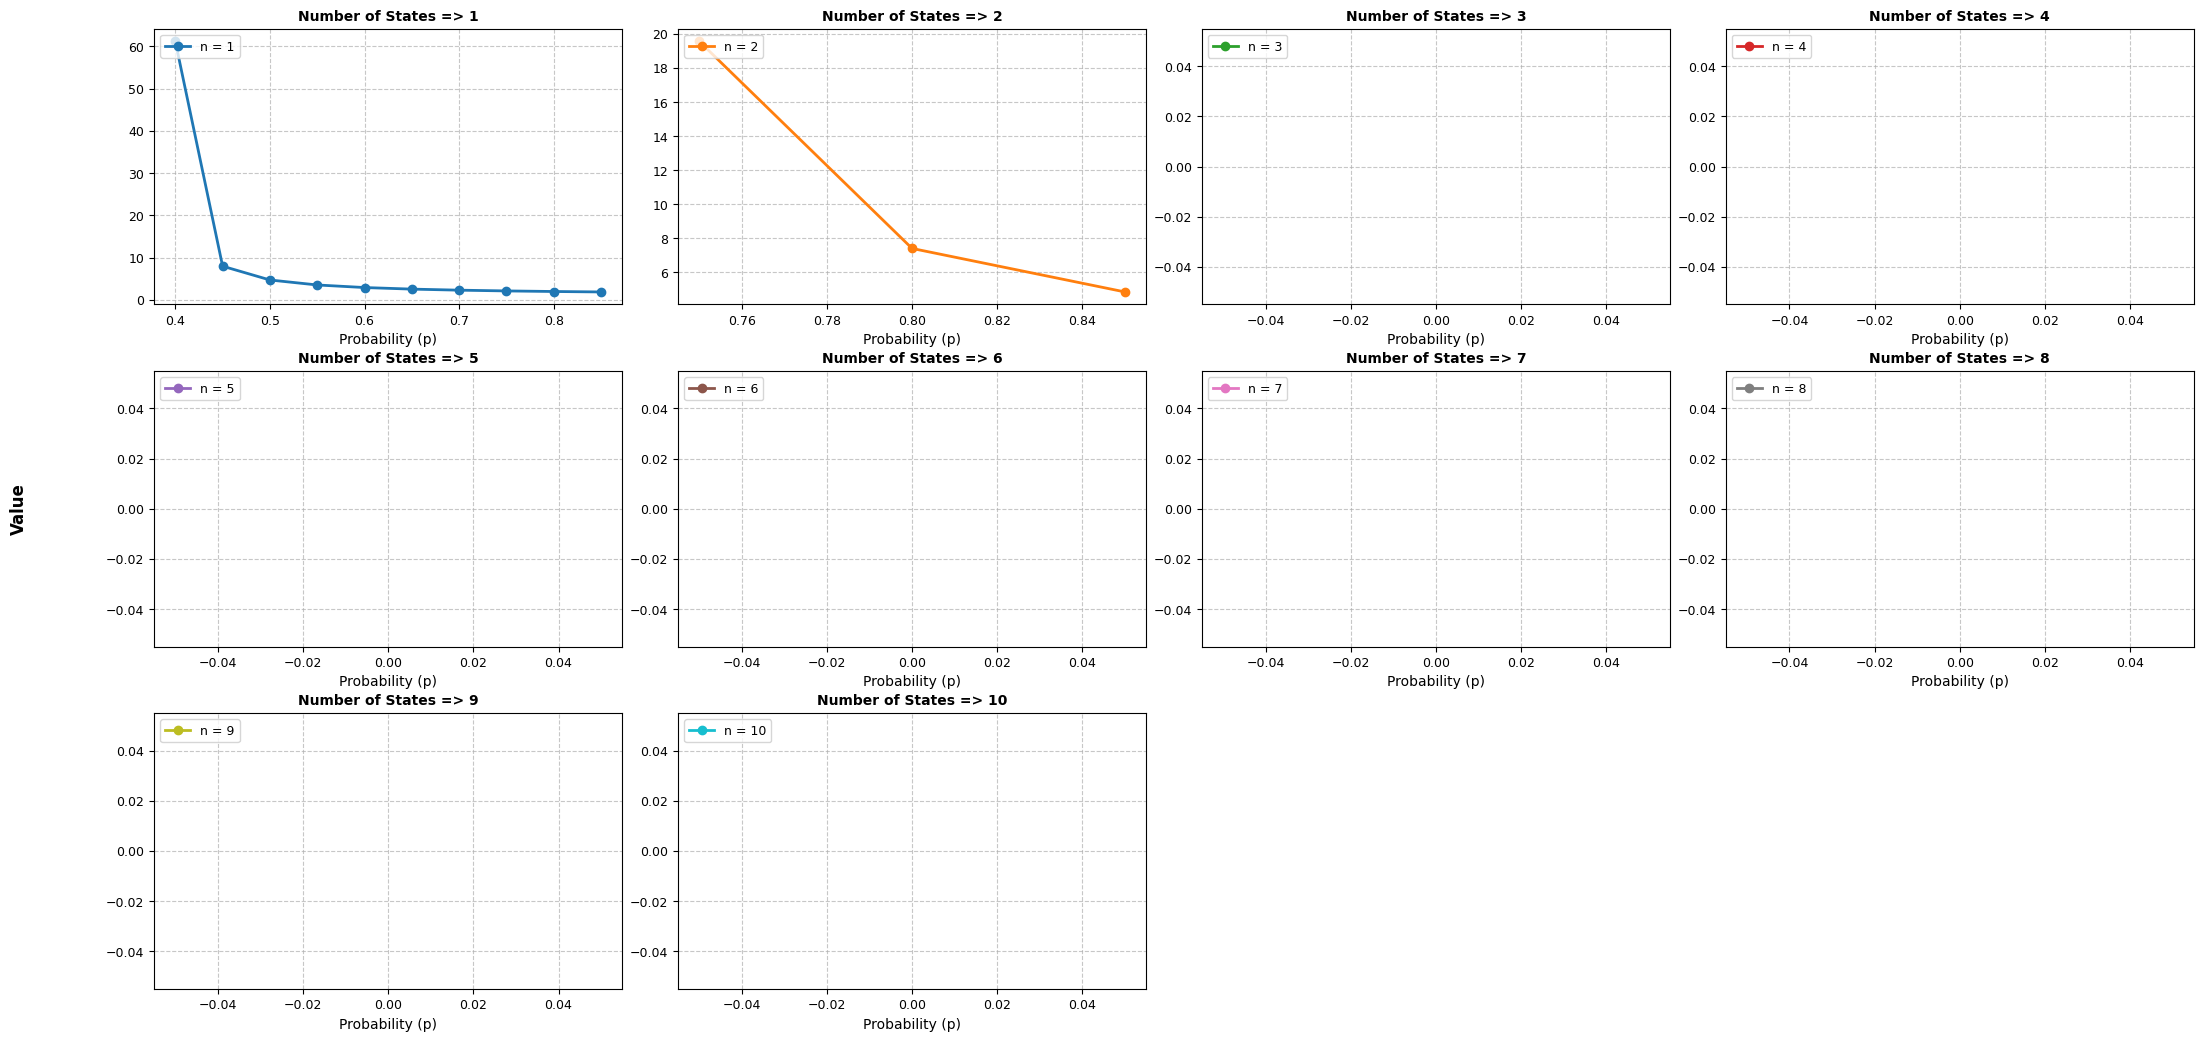

In [43]:
subplots_for_number_of_states(EXP_REGION, sharey=False)

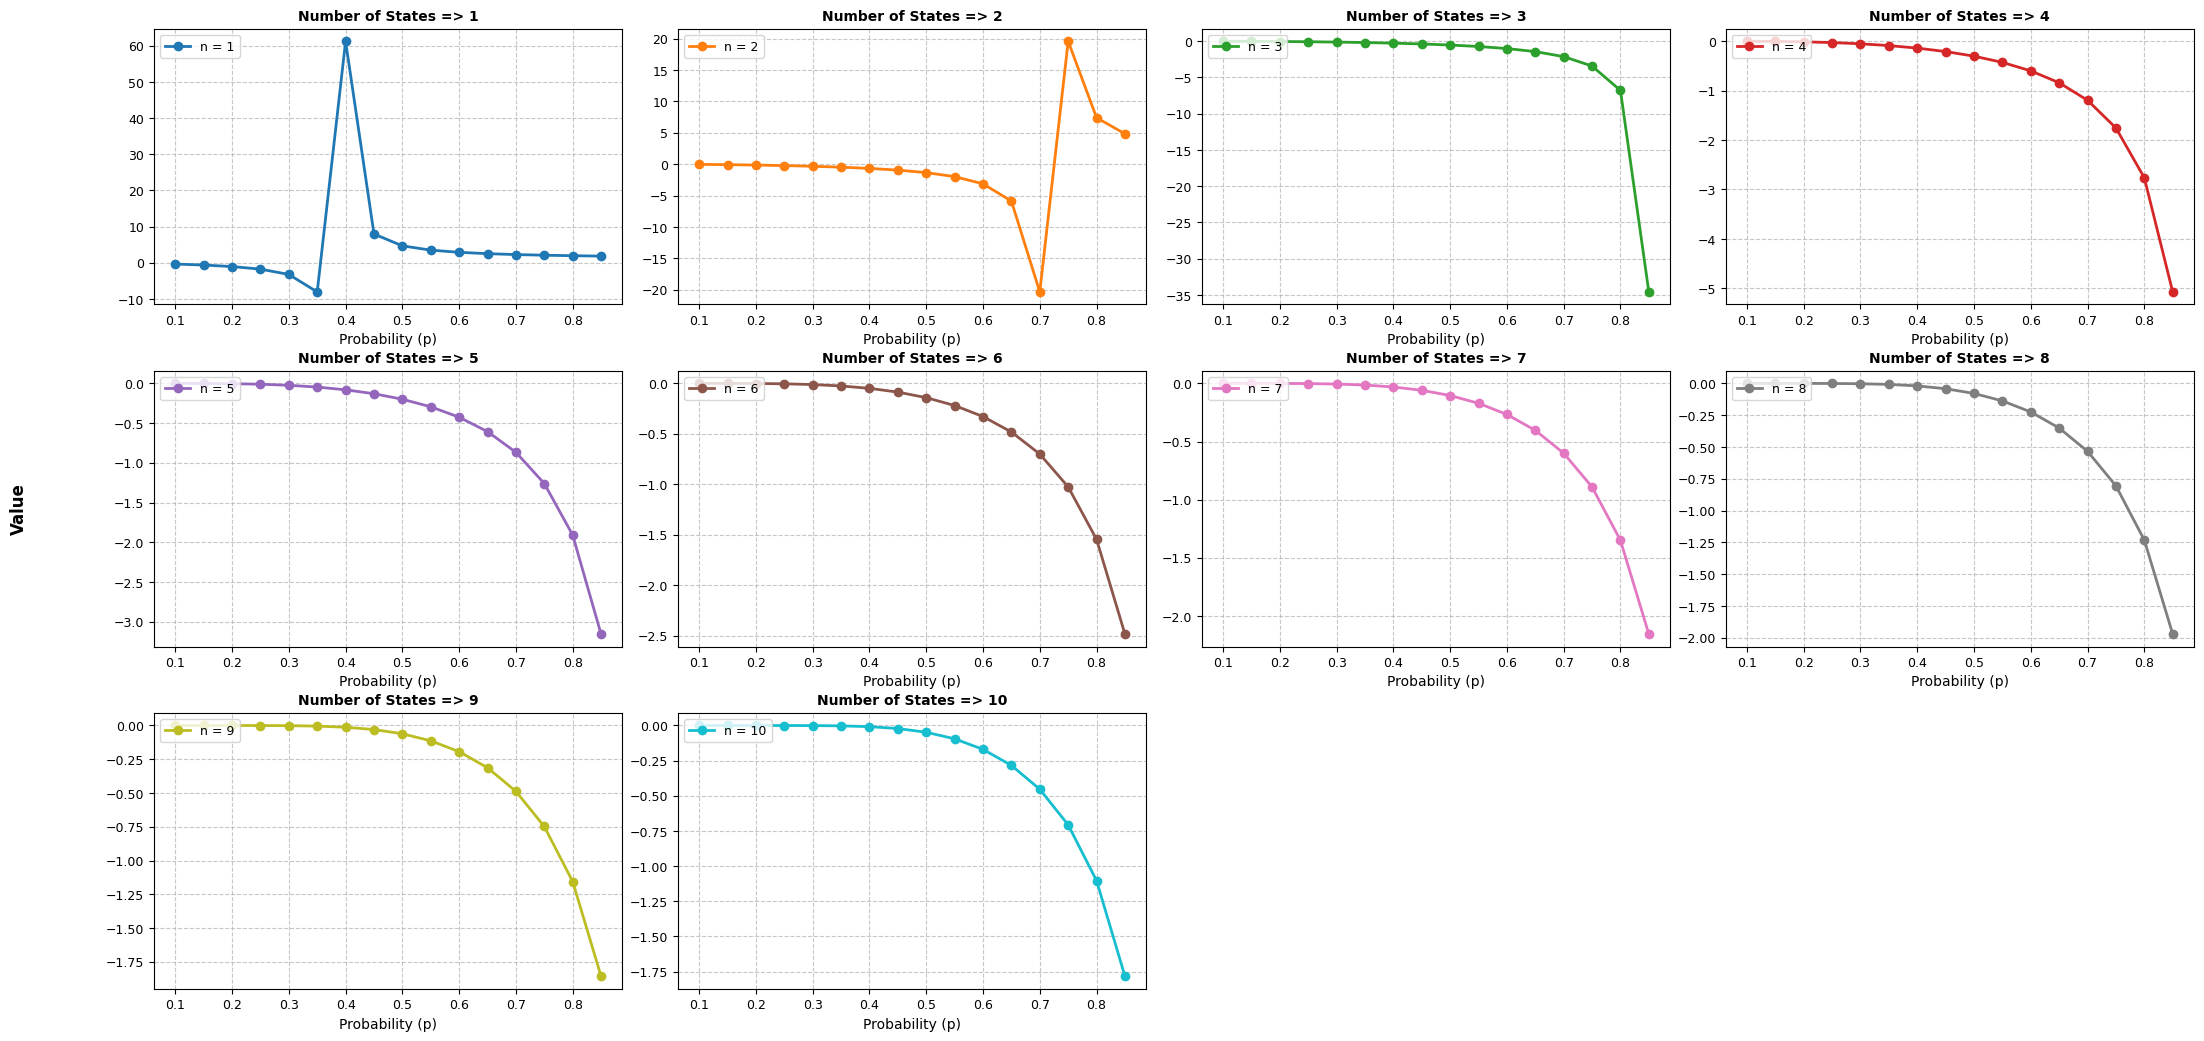

In [44]:
subplots_for_number_of_states(EXP_ANALITICO_REGION, sharey=False)

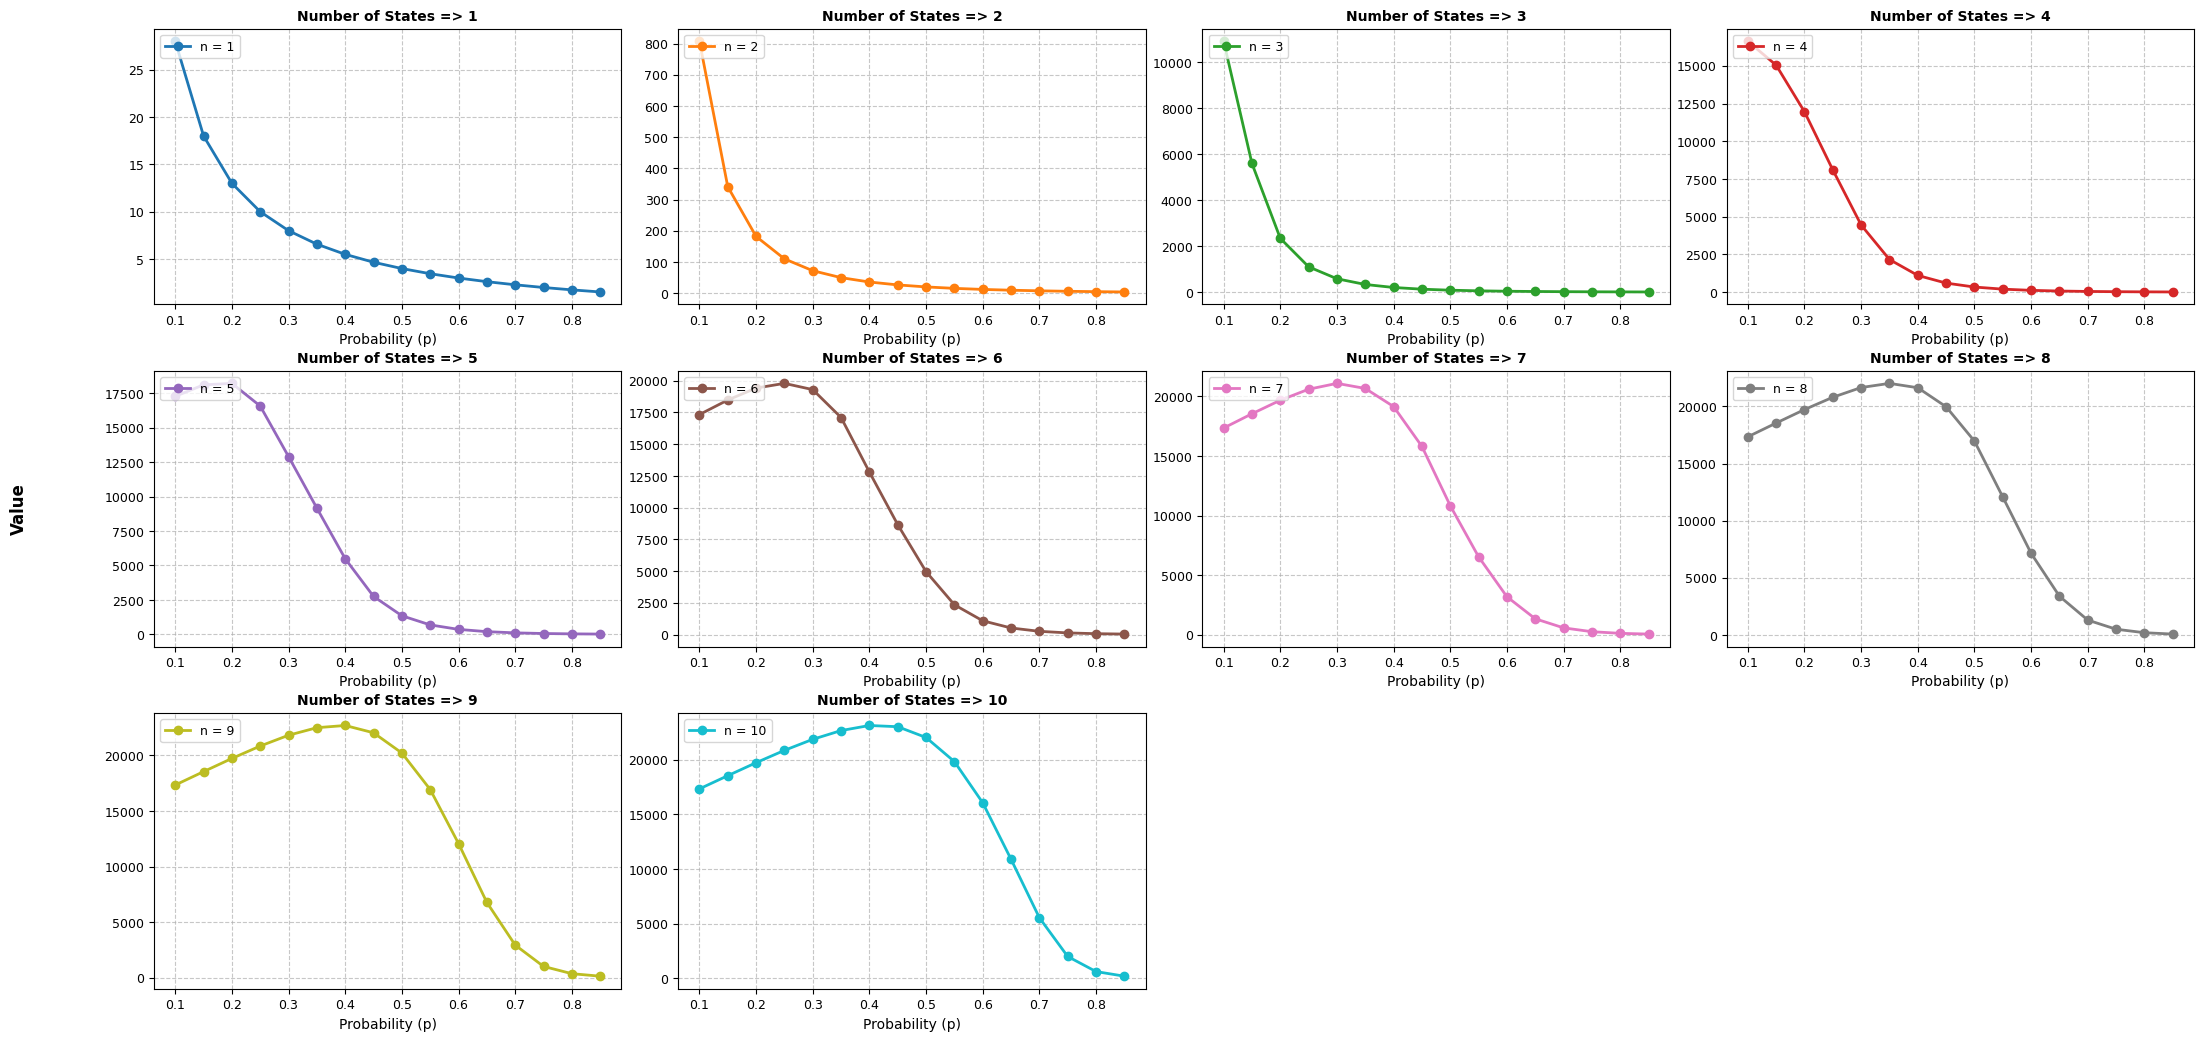

In [45]:
subplots_for_number_of_states(PLT_REGION, sharey=False)